# E3 — Cartopy Maps
Two maps: the Antarctic/Southern Ocean and the South Atlantic. Projections chosen based on the region — polar stereographic for the pole, Plate Carrée for the mid-latitude regional view.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import warnings
warnings.filterwarnings('ignore')

In [2]:
# shared style — centralised so both maps stay consistent
OCEAN_COLOR   = '#cce5f0'
LAND_COLOR    = '#e8dcc8'
ICE_COLOR     = '#f0f4f8'
COAST_COLOR   = '#4a4a4a'
GRID_COLOR    = '#888888'
CITY_COLOR    = '#c0392b'
HALO          = 'white'

TITLE_SIZE = 13
LABEL_SIZE = 10
TICK_SIZE  = 9

## Map 1 — Antarctic continent and Southern Ocean

South Polar Stereographic is the standard projection for polar regions — it's conformal and keeps distortion minimal near the pole. Mercator would be unusable here. The extent is set in PlateCarree coordinates and cartopy handles the reprojection into the familiar circular polar view.

One cartopy quirk worth noting: `draw_labels=True` doesn't work reliably in polar projections, so latitude and longitude labels are placed manually.

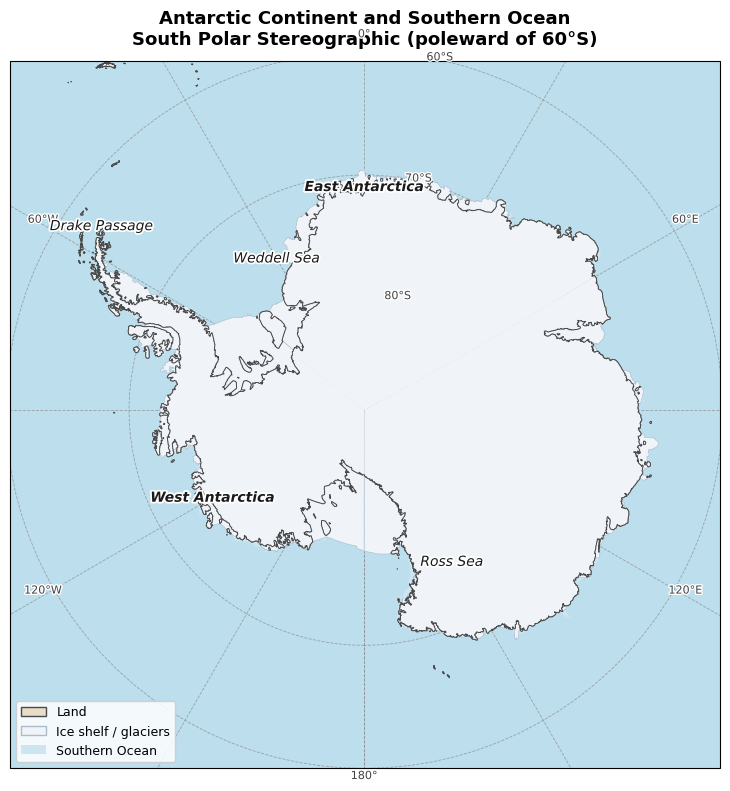

In [3]:
fig1, ax1 = plt.subplots(
    figsize=(8, 8),
    subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=0)}
)

ax1.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
ax1.set_facecolor(OCEAN_COLOR)

# 10m resolution needed — the Antarctic coastline and ice shelf geometry
# are too complex to render cleanly at coarser scales
land_10m = cfeature.NaturalEarthFeature(
    'physical', 'land', '10m',
    facecolor=LAND_COLOR, edgecolor=COAST_COLOR, linewidth=0.6
)
ice_10m = cfeature.NaturalEarthFeature(
    'physical', 'antarctic_ice_shelves_polys', '10m',
    facecolor=ICE_COLOR, edgecolor='#aabbcc', linewidth=0.4
)
glaciers = cfeature.NaturalEarthFeature(
    'physical', 'glaciated_areas', '10m',
    facecolor=ICE_COLOR, edgecolor='none'
)

# ocean base layer at lower resolution — gives a subtle tonal contrast
# between the open Southern Ocean and the near-shelf areas
ax1.add_feature(
    cfeature.NaturalEarthFeature('physical', 'ocean', '110m',
                                 facecolor='#a8d5e8', edgecolor='none'),
    zorder=1, alpha=0.4
)
ax1.add_feature(land_10m, zorder=2)
ax1.add_feature(glaciers, zorder=3)
ax1.add_feature(ice_10m,  zorder=4)
ax1.add_feature(cfeature.COASTLINE.with_scale('10m'),
                edgecolor=COAST_COLOR, linewidth=0.7, zorder=5)

# gridlines — no labels here, placed manually below
gl1 = ax1.gridlines(
    crs=ccrs.PlateCarree(),
    linewidth=0.6, color=GRID_COLOR, alpha=0.7, linestyle='--', zorder=6
)
gl1.xlocator = mticker.FixedLocator(range(-180, 181, 30))
gl1.ylocator = mticker.FixedLocator([-90, -80, -70, -60])

# latitude labels at lon=10° (just right of the 0-meridian gridline)
for lat, lab in [(-60, '60°S'), (-70, '70°S'), (-80, '80°S')]:
    ax1.text(
        10, lat, lab,
        transform=ccrs.PlateCarree(),
        fontsize=TICK_SIZE - 1, color='#444444',
        ha='left', va='center',
        path_effects=[pe.withStroke(linewidth=2, foreground=HALO)],
        zorder=7
    )

# longitude labels just outside the 60°S boundary
for lon, lab in zip(
    [-180, -120, -60, 0, 60, 120],
    ['180°', '120°W', '60°W', '0°', '60°E', '120°E']
):
    ax1.text(
        lon, -59, lab,
        transform=ccrs.PlateCarree(),
        fontsize=TICK_SIZE - 1, color='#444444',
        ha='center', va='bottom',
        path_effects=[pe.withStroke(linewidth=2, foreground=HALO)],
        zorder=7
    )

# geographic labels — italic for ocean/sea names, bold for landmasses
geo_labels = [
    (  0, -90, 'South Pole',      True),
    (-30, -75, 'Weddell Sea',     False),
    (150, -75, 'Ross Sea',        False),
    (  0, -71, 'East Antarctica', True),
    (-120,-75, 'West Antarctica', True),
    (-55, -63, 'Drake Passage',   False),
]
for lon, lat, name, bold in geo_labels:
    ax1.text(
        lon, lat, name,
        transform=ccrs.PlateCarree(),
        fontsize=LABEL_SIZE,
        fontweight='bold' if bold else 'normal',
        style='italic',
        color='#1a1a1a', ha='center', va='center',
        path_effects=[pe.withStroke(linewidth=2.5, foreground=HALO)],
        zorder=8
    )

# South Pole crosshair
ax1.plot(0, -90, marker='+', markersize=10, markeredgewidth=1.5,
         color='#333333', transform=ccrs.PlateCarree(), zorder=9)

ax1.set_title(
    'Antarctic Continent and Southern Ocean\nSouth Polar Stereographic (poleward of 60°S)',
    fontsize=TITLE_SIZE, fontweight='bold', pad=12
)

ax1.legend(
    handles=[
        mpatches.Patch(facecolor=LAND_COLOR,  edgecolor=COAST_COLOR, label='Land'),
        mpatches.Patch(facecolor=ICE_COLOR,   edgecolor='#aabbcc',   label='Ice shelf / glaciers'),
        mpatches.Patch(facecolor=OCEAN_COLOR, edgecolor='none',       label='Southern Ocean'),
    ],
    loc='lower left', fontsize=TICK_SIZE, framealpha=0.85, edgecolor='#cccccc'
)

plt.tight_layout()
plt.savefig('map1_antarctica_southern_ocean.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## Map 2 — South Atlantic (20°S to 50°S)

Plate Carrée is reasonable here — the region spans moderate latitudes where distortion is manageable and the rectilinear grid is intuitive for locating ports. The four cities are labelled with individually tuned offsets to avoid coastline overlap; a fixed offset would work for some but not all of them.

In [4]:
cities = {
    'Walvis Bay':     ( 14.505, -22.959),
    'Cape Town':      ( 18.424, -33.925),
    'Rio de Janeiro': (-43.173, -22.907),
    'Montevideo':     (-56.165, -34.901),
}

# offsets chosen per city to keep labels off the coastline
city_offsets = {
    'Walvis Bay':     ( 1.0,  1.2),
    'Cape Town':      ( 1.0, -1.8),
    'Rio de Janeiro': ( 1.0,  1.2),
    'Montevideo':     ( 1.0, -1.8),
}

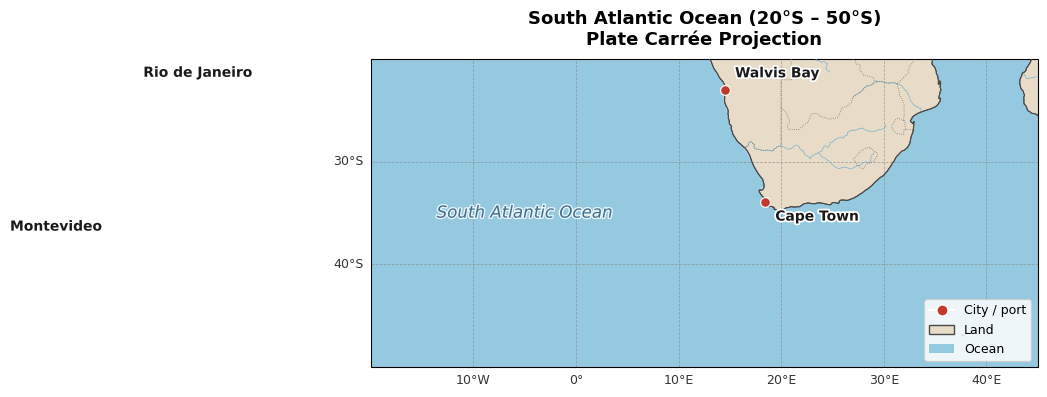

In [5]:
fig2, ax2 = plt.subplots(
    figsize=(12, 7),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

ax2.set_extent([-20, 45, -50, -20], crs=ccrs.PlateCarree())
ax2.set_facecolor(OCEAN_COLOR)

# darker ocean base gives a subtle depth contrast without needing a bathymetry file
ax2.add_feature(
    cfeature.NaturalEarthFeature('physical', 'ocean', '110m',
                                 facecolor='#94c9e0', edgecolor='none'),
    zorder=1
)

ax2.add_feature(
    cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                 facecolor=LAND_COLOR, edgecolor=COAST_COLOR,
                                 linewidth=0.7),
    zorder=2
)
ax2.add_feature(
    cfeature.NaturalEarthFeature('physical', 'lakes', '50m',
                                 facecolor='#aaccdd', edgecolor='#7ab3cc',
                                 linewidth=0.4),
    zorder=3
)
# rivers help contextualise port cities — especially the Rio de la Plata
ax2.add_feature(
    cfeature.NaturalEarthFeature('physical', 'rivers_lake_centerlines', '50m',
                                 facecolor='none', edgecolor='#7ab3cc',
                                 linewidth=0.5),
    zorder=3
)
ax2.add_feature(cfeature.BORDERS.with_scale('50m'),
                edgecolor='#777777', linewidth=0.6, linestyle=':', zorder=4)
ax2.add_feature(cfeature.COASTLINE.with_scale('50m'),
                edgecolor=COAST_COLOR, linewidth=0.8, zorder=5)

gl2 = ax2.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.55, color=GRID_COLOR, alpha=0.7, linestyle='--', zorder=6
)
gl2.top_labels   = False
gl2.right_labels = False
gl2.xformatter   = LONGITUDE_FORMATTER
gl2.yformatter   = LATITUDE_FORMATTER
gl2.xlabel_style = {'size': TICK_SIZE, 'color': '#333333'}
gl2.ylabel_style = {'size': TICK_SIZE, 'color': '#333333'}
gl2.xlocator = mticker.FixedLocator(range(-20, 46, 10))
gl2.ylocator = mticker.FixedLocator(range(-50, -19, 10))

for city, (lon, lat) in cities.items():
    ax2.plot(lon, lat,
             marker='o', markersize=7, color=CITY_COLOR,
             markeredgecolor='white', markeredgewidth=0.8,
             transform=ccrs.PlateCarree(), zorder=9)
    dlon, dlat = city_offsets[city]
    ax2.text(
        lon + dlon, lat + dlat, city,
        transform=ccrs.PlateCarree(),
        fontsize=LABEL_SIZE, fontweight='bold', color='#1a1a1a',
        path_effects=[pe.withStroke(linewidth=2.5, foreground=HALO)],
        zorder=10
    )

ax2.text(
    -5, -35, 'South Atlantic Ocean',
    transform=ccrs.PlateCarree(),
    fontsize=12, style='italic', color='#1a5276',
    ha='center', va='center', alpha=0.8,
    path_effects=[pe.withStroke(linewidth=2, foreground='white')],
    zorder=7
)

ax2.set_title(
    'South Atlantic Ocean (20°S – 50°S)\nPlate Carrée Projection',
    fontsize=TITLE_SIZE, fontweight='bold', pad=10
)

ax2.legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=CITY_COLOR, markeredgecolor='white',
                   markersize=8, label='City / port'),
        mpatches.Patch(facecolor=LAND_COLOR, edgecolor=COAST_COLOR, label='Land'),
        mpatches.Patch(facecolor='#94c9e0',  edgecolor='none',      label='Ocean'),
    ],
    loc='lower right', fontsize=TICK_SIZE, framealpha=0.85, edgecolor='#cccccc'
)

plt.tight_layout()
plt.savefig('map2_south_atlantic.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()